# Wind-Tunnel Acoustic Anomaly Detection
### FARM Data Science Challenge

**Problem statement:** During wind-tunnel test campaigns, acoustic sensors occasionally
emit non-physical spikes from transient instrument faults, forcing engineers to inspect
raw logs by hand. We ask whether ML can (a) model expected acoustic behaviour and
(b) detect anomalous sound-pressure readings.

"Anomaly" hides three failure modes:
Invalid inputs (hard physics bounds), out-of-domain inputs
(low-confidence flag), anomalous **SPL readings** (regression residual).

## 1. Setup & reproducibility

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

import wt_noise_lib as wtai
from wt_noise_lib import config, models, metrics, validation, anomaly
from sklearn.preprocessing import StandardScaler

sns.set_theme(style="whitegrid", context="notebook")
wtai.set_seed()
print("wt_noise_lib", wtai.__version__, "| global seed:", config.RANDOM_SEED)

wt_noise_lib 0.1.0 | global seed: 42


## 2. Data loading
Load the raw tab-separated file into a typed, named DataFrame (1,503 rows, 5 inputs + SPL).

In [2]:
df = wtai.load_data()
print("shape:", df.shape)
print(df.dtypes.to_string())
df.head()

shape: (1503, 6)
frequency_hz                 int64
angle_of_attack_deg        float64
chord_length_m             float64
free_stream_velocity_ms    float64
suction_displacement_m     float64
sound_pressure_db          float64


,frequency_hz,angle_of_attack_deg,chord_length_m,free_stream_velocity_ms,suction_displacement_m,sound_pressure_db
0,800,0.0,0.3048,71.3,0.002663,126.201
1,1000,0.0,0.3048,71.3,0.002663,125.201
2,1250,0.0,0.3048,71.3,0.002663,125.951
3,1600,0.0,0.3048,71.3,0.002663,127.591
4,2000,0.0,0.3048,71.3,0.002663,127.461


## 3. Statistical sanity checks
The brief *claims* the data is clean — we verify rather than trust, and read a short
story from the numbers.

In [3]:
summary = df.describe().T[["min", "mean", "50%", "max", "std"]]
print("missing values:", int(df.isna().sum().sum()),
      "| exact duplicate rows:", int(df.duplicated().sum()))
summary

missing values: 0 | exact duplicate rows: 0


,min,mean,50%,max,std
frequency_hz,200.000000,2886.380572,1600.000000,20000.000000,3152.573137
angle_of_attack_deg,0.000000,6.782302,5.400000,22.200000,5.918128
chord_length_m,0.025400,0.136548,0.101600,0.304800,0.093541
free_stream_velocity_ms,31.700000,50.860745,39.600000,71.300000,15.572784
suction_displacement_m,0.000401,0.011140,0.004957,0.058411,0.013150
sound_pressure_db,103.380000,124.835943,125.721000,140.987000,6.898657


In [4]:
spl = df[config.TARGET_COLUMN]
print("- Sanity check on clean data.")
print(f"- SPL spans {spl.min():.1f}–{spl.max():.1f} dB (mean {spl.mean():.1f}).")
print(f"- Frequency spans {df.frequency_hz.min():.0f}–{df.frequency_hz.max():.0f} Hz .")
print(f"- Angle of attack {df.angle_of_attack_deg.min():.1f}–{df.angle_of_attack_deg.max():.1f} deg")

- Sanity check on clean data.
- SPL spans 103.4–141.0 dB (mean 124.8).
- Frequency spans 200–20000 Hz .
- Angle of attack 0.0–22.2 deg


## 4. Visual Checks
Distributions, target-vs-feature relationships, and correlations — with an insight per view.

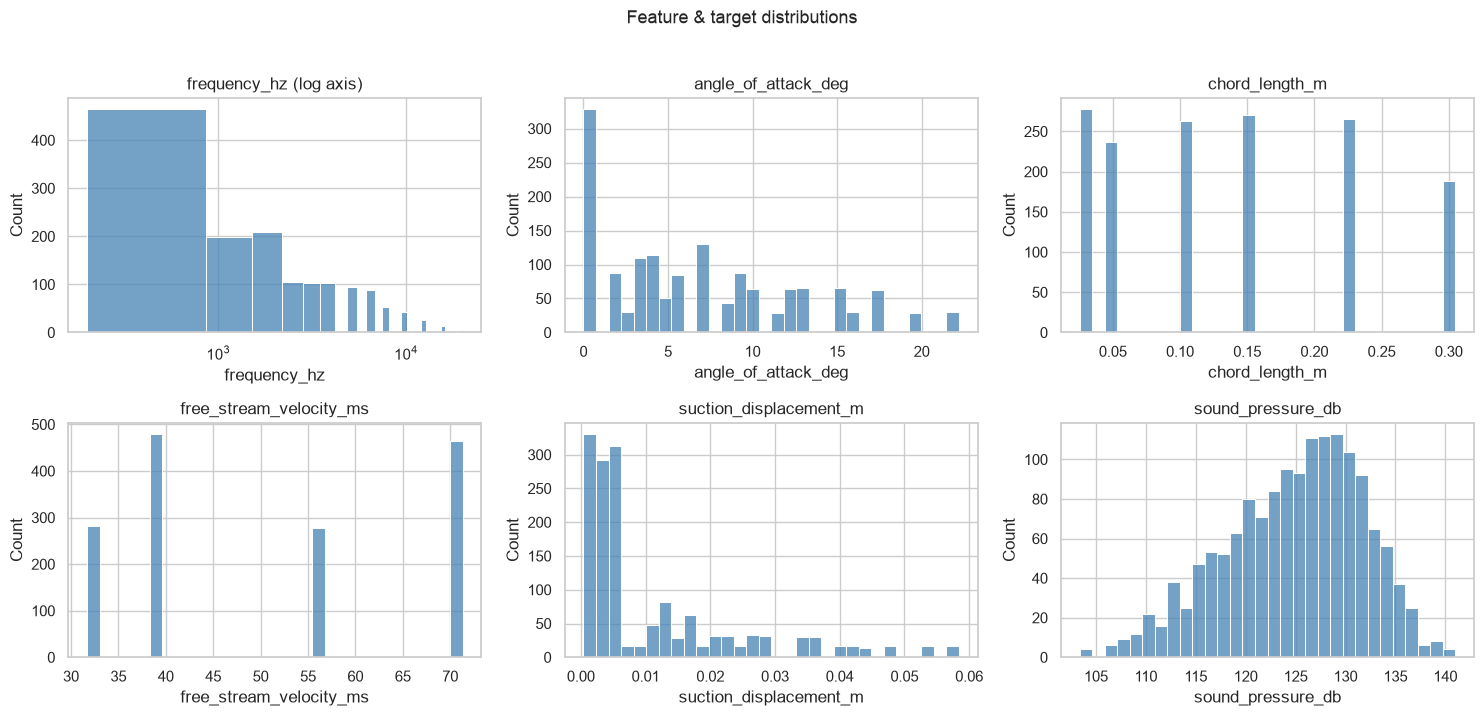

In [5]:
fig, axes = plt.subplots(2, 3, figsize=(15, 7))
for ax, col in zip(axes.ravel(), config.COLUMNS):
    sns.histplot(df[col], ax=ax, bins=30, color="steelblue")
    ax.set_title(col)
    if col == "frequency_hz":
        ax.set_xscale("log"); ax.set_title("frequency_hz (log axis)")
fig.suptitle("Feature & target distributions", y=1.02, fontsize=13)
plt.tight_layout(); plt.show()

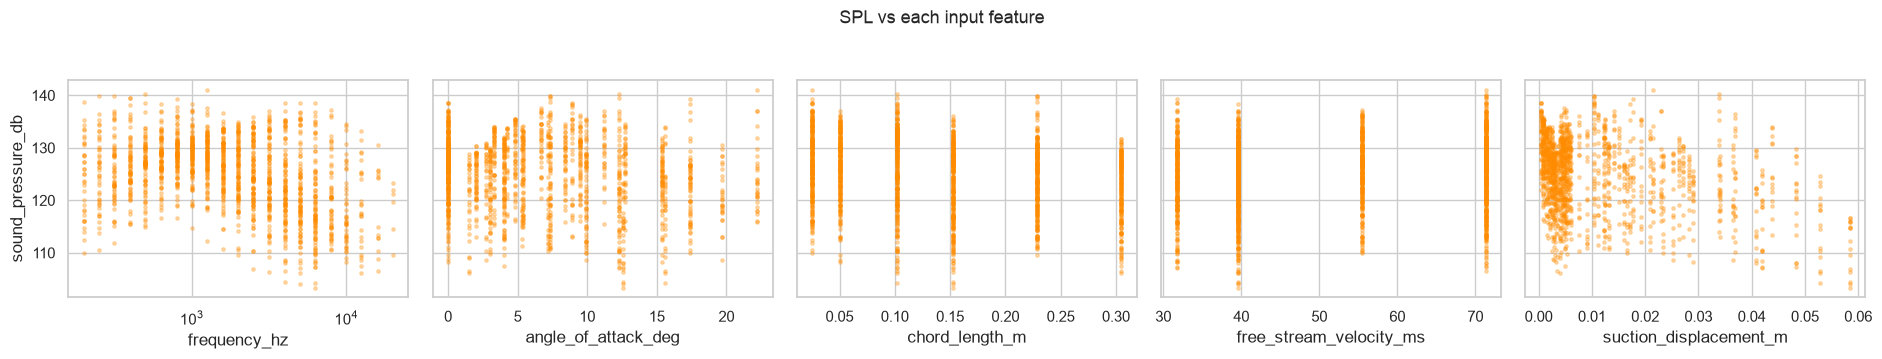

In [6]:
fig, axes = plt.subplots(1, 5, figsize=(19, 3.4), sharey=True)
for ax, col in zip(axes, config.FEATURE_COLUMNS):
    ax.scatter(df[col], df[config.TARGET_COLUMN], s=6, alpha=0.3, color="darkorange")
    ax.set_xlabel(col);
    if col == "frequency_hz": ax.set_xscale("log")
axes[0].set_ylabel("sound_pressure_db")
fig.suptitle("SPL vs each input feature", y=1.05, fontsize=13)
plt.tight_layout(); plt.show()

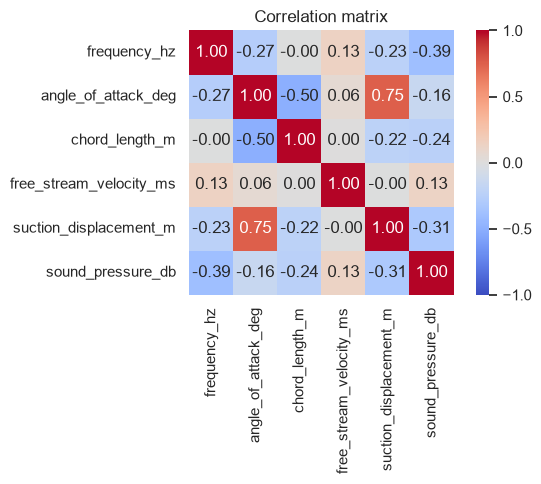

Correlation of each feature with SPL:
frequency_hz              -0.390711
suction_displacement_m    -0.312670
chord_length_m            -0.236162
angle_of_attack_deg       -0.156108
free_stream_velocity_ms    0.125103


In [7]:
corr = df.corr(numeric_only=True)
plt.figure(figsize=(6.5, 5))
# Pearson r is already normalised to [-1, 1]; pin the colour scale to the full
# range so a colour always means the same value (autoscaling had capped it at
# the data max of -0.39..1.0, making weak correlations look stronger).
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0,
            vmin=-1, vmax=1, square=True, cbar_kws={"ticks": [-1, -0.5, 0, 0.5, 1]})
plt.title("Correlation matrix"); plt.tight_layout(); plt.show()

tcorr = corr[config.TARGET_COLUMN].drop(config.TARGET_COLUMN).sort_values()
print("Correlation of each feature with SPL:")
print(tcorr.to_string())

**Insights.**
- **Frequency** is the dominant driver and is *non-linear*: SPL rises then falls across spectrum.
- **Angle of attack** and **suction-side displacement** are strongly related (displacement is
  a boundary-layer consequence of AoA).
- No single feature is linearly dominant (|corr| are moderate).

## 5. Physics validity bounds
Hard, spec-derived bounds reject physically impossible quantities **before** the model sees it
(answers: what if AoA = 236758°? due to some random fault).

In [8]:
demo = pd.DataFrame([
    {"frequency_hz":1000,"angle_of_attack_deg":5.0,"chord_length_m":0.1,
     "free_stream_velocity_ms":55.5,"suction_displacement_m":0.005,"sound_pressure_db":125.0},
    {"frequency_hz":1000,"angle_of_attack_deg":236758.0,"chord_length_m":0.1,
     "free_stream_velocity_ms":55.5,"suction_displacement_m":0.005,"sound_pressure_db":125.0},
    {"frequency_hz":-5,"angle_of_attack_deg":5.0,"chord_length_m":0.1,
     "free_stream_velocity_ms":55.5,"suction_displacement_m":0.005,"sound_pressure_db":125.0},
])
validation.validate_physical(demo)[["angle_of_attack_deg","frequency_hz",
                                    "is_physically_valid","violation"]]

,angle_of_attack_deg,frequency_hz,is_physically_valid,violation
0,5.0,1000,True,
1,236758.0,1000,False,angle_of_attack_deg > 90.0
2,5.0,-5,False,frequency_hz < 0.0


The impossible AoA and the negative frequency are rejected deterministically with a
reason string. AI is never asked to learn on such data.

## 6. Acoustic-spectrum check
For a fixed configuration the data is an **SPL spectrum** across frequency. A physical spectrum should be smooth and fall at high
frequency. This is consistent with physics as well.

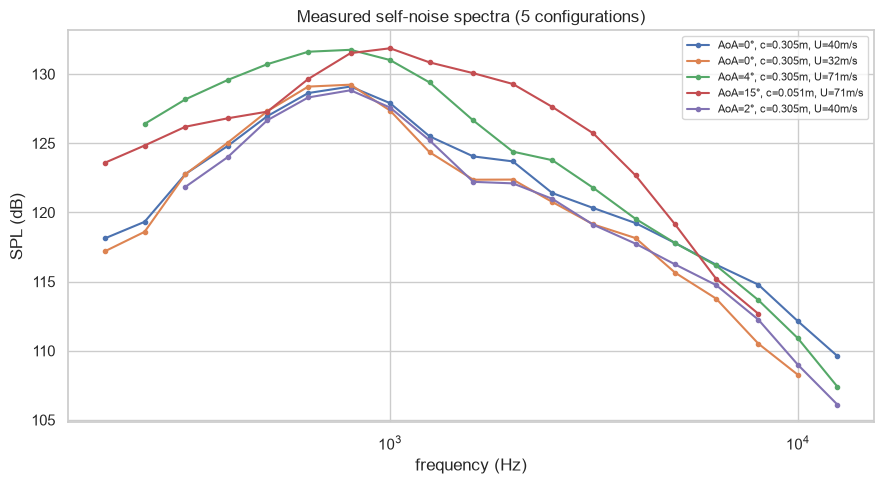

In [9]:
grp = df.groupby(config.CONFIG_COLUMNS, sort=False)
sizes = grp.size().sort_values(ascending=False)
plt.figure(figsize=(9, 5))
for key in sizes.index[:5]:
    sub = grp.get_group(key).sort_values("frequency_hz")
    label = f"AoA={key[0]:.0f}°, c={key[1]:.3f}m, U={key[2]:.0f}m/s"
    plt.plot(sub.frequency_hz, sub[config.TARGET_COLUMN], marker="o", ms=3, label=label)
plt.xscale("log"); plt.xlabel("frequency (Hz)"); plt.ylabel("SPL (dB)")
plt.title("Measured self-noise spectra (5 configurations)")
plt.legend(fontsize=8); plt.tight_layout(); plt.show()

Above image shows the rise and fall nature of SPL with frequency.

## 7. Detecting low-confidence samples
A physically valid input can still be *unseen* (e.g. an AoA beyond the tested range). The
prediction there is an untrustworthy extrapolation, so we **flag it low-confidence** rather
than reject or blindly trust.

In [10]:
ood = validation.OODDetector().fit(df[config.FEATURE_COLUMNS])

in_domain = df[config.FEATURE_COLUMNS].iloc[[0]]
far = in_domain.copy(); far["angle_of_attack_deg"] = df.angle_of_attack_deg.max() + 25.0
print("real in-domain row flagged as low-confidence? ", bool(ood.predict(in_domain).iloc[0]))
print(f"AoA = {float(far.angle_of_attack_deg.iloc[0]):.1f}° (beyond tested "
      f"max {df.angle_of_attack_deg.max():.1f}°) flagged low-confidence? ", bool(ood.predict(far).iloc[0]))

real in-domain row flagged as low-confidence?  False
AoA = 47.2° (beyond tested max 22.2°) flagged low-confidence?  True


## 8. Grouped train/val/test split
Rows sharing a configuration differ only in the swept frequency, so they are near-siblings. We split **by
configuration** so every evaluation is on a well-balanced dataset.

In [11]:
train_df, val_df, test_df = wtai.grouped_split(df)
for name, part in [("train", train_df), ("val", val_df), ("test", test_df)]:
    n_cfg = part.groupby(config.CONFIG_COLUMNS, sort=False).ngroups
    print(f"{name:5s}: {len(part):4d} rows  |  {n_cfg:3d} configurations")

def cfgset(p): return set(map(tuple, p[config.CONFIG_COLUMNS].to_numpy()))
assert cfgset(train_df).isdisjoint(cfgset(test_df))
assert cfgset(train_df).isdisjoint(cfgset(val_df))
assert cfgset(val_df).isdisjoint(cfgset(test_df))
print("\nDiversity and representation is ensure in each group. And no configuration sharing happens amidst the groups to best test the models.")

train:  944 rows  |   67 configurations
val  :  242 rows  |   17 configurations
test :  317 rows  |   22 configurations

Diversity and representation is ensure in each group. And no configuration sharing happens amidst the groups to best test the models.


## 9. Scaling
1. Trees are scale-invariant. They train on **raw** features. 
2. Neural nets need conditioned inputs → features **and** target standardised, fit on **train only** (no leakage), and NN
predictions are inverse-transformed back to dB before any residual is computed.

In [12]:
feat, tgt = config.FEATURE_COLUMNS, config.TARGET_COLUMN

X_train_raw, y_train = train_df[feat].to_numpy(), train_df[tgt].to_numpy()
X_val_raw,   y_val   = val_df[feat].to_numpy(),   val_df[tgt].to_numpy()
X_test_raw,  y_test  = test_df[feat].to_numpy(),  test_df[tgt].to_numpy()

scaler_X = StandardScaler().fit(X_train_raw)
scaler_y = StandardScaler().fit(y_train.reshape(-1, 1))
Xtr, Xva, Xte = (scaler_X.transform(a) for a in (X_train_raw, X_val_raw, X_test_raw))
ytr_s = scaler_y.transform(y_train.reshape(-1, 1)).ravel()
yva_s = scaler_y.transform(y_val.reshape(-1, 1)).ravel()

def to_db(scaled):  # inverse-transform NN outputs back to dB
    return scaler_y.inverse_transform(np.asarray(scaled).reshape(-1, 1)).ravel()

print("scaler fit on train only — feature means ≈ 0:", np.round(Xtr.mean(0), 3))

scaler fit on train only — feature means ≈ 0: [ 0.  0. -0.  0. -0.]


## 10. Metrics
We commit to metrics at this stage.

**Regression**
- **RMSE (dB)** — squares errors, so it penalises the large deviations that matter for severe faults
- **MAE (dB)** — typical error magnitude, robust to a few outliers.
- **R²** — fraction of SPL variance explained; unitless, comparable across models.

**Detection**
- **PR-AUC** — primary: anomalies are rare, so precision/recall is more honest than accuracy.
- **ROC-AUC** — reported for completeness; Precision/Recall/F1 at the operating threshold.

In [13]:
baseline_rmse = float(np.sqrt(np.mean((y_test - y_train.mean())**2)))
print(f"mean-predictor test RMSE = {baseline_rmse:.2f} dB (the floor any model must beat)")

mean-predictor test RMSE = 7.17 dB (the floor any model must beat)


## 11. Models
In order, folloing models are explored:
1. Linear
2. RandomForest
3. HistGradientBoosting**
4. **two PyTorch MLPs** (a compact net and a deeper variant, on
scaled inputs).

In [14]:
preds_val, preds_test, trained = {}, {}, {}

# --- classical baselines on RAW features ---
for name, model in models.get_baseline_models().items():
    model.fit(X_train_raw, y_train)
    preds_val[name]  = model.predict(X_val_raw)
    preds_test[name] = model.predict(X_test_raw)
    trained[name] = model
print("classical models trained:", list(trained.keys()))

classical models trained: ['linear', 'random_forest', 'hist_gbdt']


In [15]:
# --- PyTorch MLPs on SCALED features + target ---
mlp_specs = {"mlp_64x64": (64, 64), "mlp_deep_128x128x64": (128, 128, 64)}
for name, hidden in mlp_specs.items():
    wtai.set_seed()  # identical init/order across runs
    net = models.build_mlp(input_dim=Xtr.shape[1], hidden=hidden, dropout=0.1)
    net, hist = models.train_mlp(net, Xtr, ytr_s, Xva, yva_s, epochs=400, patience=40)
    preds_val[name]  = to_db(models.mlp_predict(net, Xva))
    preds_test[name] = to_db(models.mlp_predict(net, Xte))
    trained[name] = net
    print(f"{name:22s} trained — stopped after {len(hist['train_loss'])} epochs")

mlp_64x64              trained — stopped after 129 epochs
mlp_deep_128x128x64    trained — stopped after 129 epochs


## 12. Tuning & comparison
Model selection uses the **validation** set; the **test** set is touched once. We then compare baseline ML versus deep learning models

In [16]:
rows = []
for name in trained:
    mv = metrics.regression_metrics(y_val,  preds_val[name])
    mt = metrics.regression_metrics(y_test, preds_test[name])
    rows.append({"model":name, "val_RMSE":mv["rmse_db"], "test_RMSE":mt["rmse_db"],
                 "test_MAE":mt["mae_db"], "test_R2":mt["r2"]})
results = pd.DataFrame(rows).sort_values("val_RMSE").reset_index(drop=True)
best_name = results.iloc[0]["model"]
results.round(3)

,model,val_RMSE,test_RMSE,test_MAE,test_R2
0,mlp_deep_128x128x64,2.442,3.086,2.186,0.804
1,mlp_64x64,2.502,3.379,2.377,0.765
2,random_forest,2.587,3.884,2.794,0.689
3,hist_gbdt,2.825,3.693,2.723,0.719
4,linear,5.055,5.018,3.725,0.481


In [17]:
best_model_is_dl = best_name.startswith("mlp")
best_dl  = results[results.model.str.startswith("mlp")].sort_values("val_RMSE").iloc[0]
best_cls = results[~results.model.str.startswith("mlp")].sort_values("val_RMSE").iloc[0]
print(f"Best overall by validation RMSE: {best_name}")
print(f"Best classical: {best_cls.model} (test RMSE {best_cls.test_RMSE:.3f} dB)")
print(f"Best deep-net : {best_dl.model} (test RMSE {best_dl.test_RMSE:.3f} dB)")
print()
if best_model_is_dl:
    print("VERDICT: deep learning wins here — but note the margin over the tree baseline below.")
else:
    print("VERDICT: a classical tree model beats both PyTorch nets on this ~1,500-row tabular")
    print("problem. Deep learning is NOT automatically best; the evidence favours the baseline.")
print(f"gap (best DL − best classical) = {best_dl.test_RMSE - best_cls.test_RMSE:+.3f} dB RMSE")

Best overall by validation RMSE: mlp_deep_128x128x64
Best classical: random_forest (test RMSE 3.884 dB)
Best deep-net : mlp_deep_128x128x64 (test RMSE 3.086 dB)

VERDICT: deep learning wins here — but note the margin over the tree baseline below.
gap (best DL − best classical) = -0.798 dB RMSE


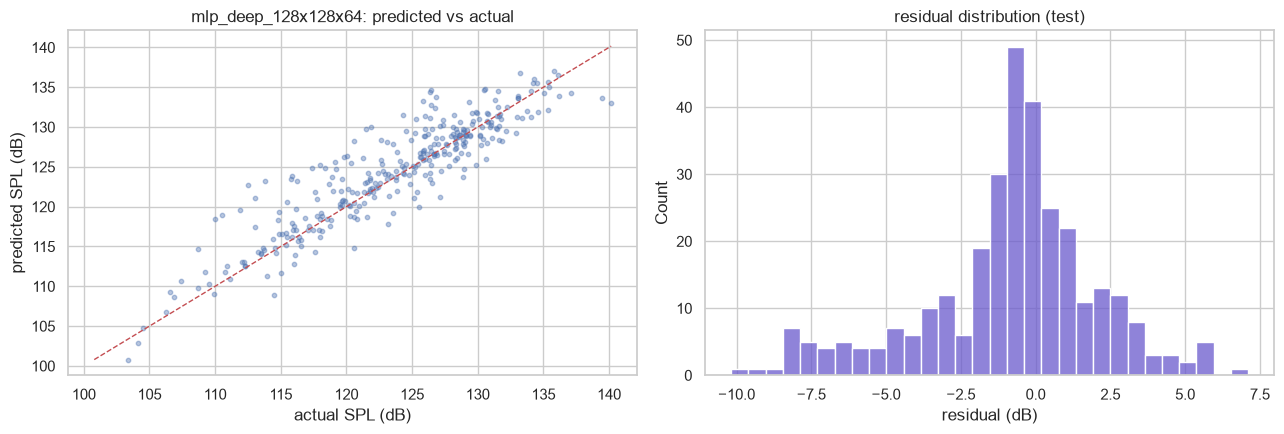

chosen model 'mlp_deep_128x128x64': test residual std = 2.972 dB


In [18]:
# diagnostics for the chosen model
yhat = preds_test[best_name]
resid = y_test - yhat
fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))
ax[0].scatter(y_test, yhat, s=10, alpha=0.4)
lim = [min(y_test.min(), yhat.min()), max(y_test.max(), yhat.max())]
ax[0].plot(lim, lim, "r--", lw=1); ax[0].set_xlabel("actual SPL (dB)")
ax[0].set_ylabel("predicted SPL (dB)"); ax[0].set_title(f"{best_name}: predicted vs actual")
sns.histplot(resid, bins=30, ax=ax[1], color="slateblue")
ax[1].set_xlabel("residual (dB)"); ax[1].set_title("residual distribution (test)")
plt.tight_layout(); plt.show()
print(f"chosen model '{best_name}': test residual std = {resid.std():.3f} dB")

## 13. Synthetic anomaly injection
The data has no real faults, so we manufacture a **labelled** test bed. Faults are modelled as
**instrument faults on the acoustic channel**: only `sound_pressure_db` is corrupted (inputs
stay clean). Additive dB spikes at three severities, both signs, seeded.

**Physics-backed magnitudes.** We size the spikes relative to the model's clean residual
scale σ (above): 
*low* ≈ a few σ (subtle, near the noise floor and genuinely hard),
*severe* ≈ an order of magnitude beyond σ (unambiguous). This mirrors real sensor glitches,
which range from marginal drift to gross dropouts.

In [19]:
sigma = resid.std()
print(f"clean residual sigma ≈ {sigma:.2f} dB → severity bands in units of sigma:")
for lvl,(lo,hi) in config.SEVERITY_DB.items():
    print(f"  {lvl:9s}: {lo:.0f}–{hi:.0f} dB  ≈ {lo/sigma:.1f}–{hi/sigma:.1f} sigma")

inj = anomaly.inject_spikes(y_test, fraction=config.INJECTION_FRACTION, seed=config.RANDOM_SEED)
print(f"\ninjected {inj.is_anomaly.sum()} / {len(y_test)} test points "
      f"({inj.is_anomaly.mean()*100:.0f}%). Only the SPL target was altered.")

clean residual sigma ≈ 2.97 dB → severity bands in units of sigma:
  low      : 3–6 dB  ≈ 1.0–2.0 sigma
  moderate : 6–12 dB  ≈ 2.0–4.0 sigma
  severe   : 12–25 dB  ≈ 4.0–8.4 sigma

injected 32 / 317 test points (10%). Only the SPL target was altered.


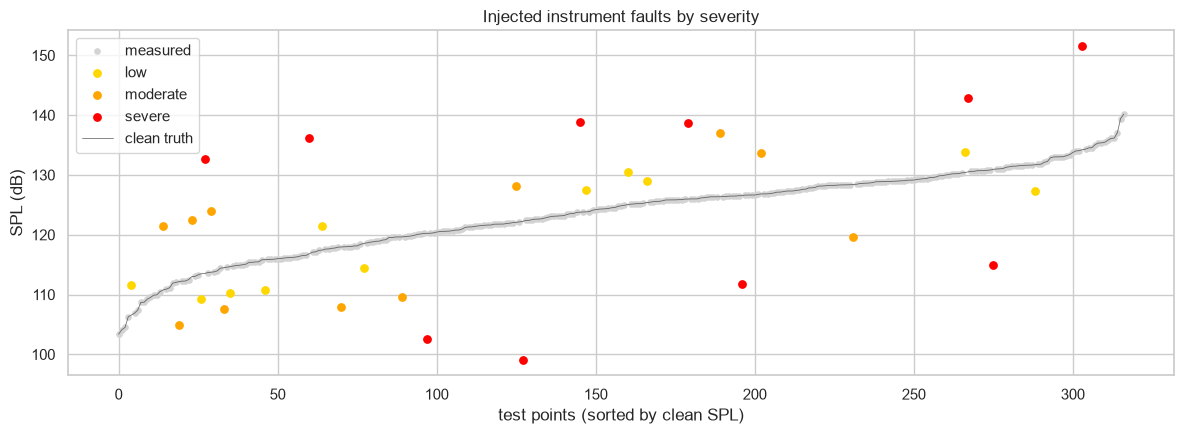

In [20]:
order = np.argsort(y_test)
plt.figure(figsize=(12, 4.5))
plt.scatter(range(len(y_test)), inj.values[order], s=14, c="lightgrey", label="measured")
for lvl, colr in [("low","gold"),("moderate","orange"),("severe","red")]:
    m = (inj.severity[order] == lvl)
    plt.scatter(np.where(m)[0], inj.values[order][m], s=28, c=colr, label=lvl, zorder=3)
plt.plot(range(len(y_test)), y_test[order], "k-", lw=0.6, alpha=0.6, label="clean truth")
plt.xlabel("test points (sorted by clean SPL)"); plt.ylabel("SPL (dB)")
plt.title("Injected instrument faults by severity"); plt.legend(); plt.tight_layout(); plt.show()

## 14. Residual-based detection
The regressor encodes *expected* SPL; a large gap between measured and expected flags a
likely fault. **Crucial:** the threshold is calibrated on **clean** train/val residuals not on the injected test set (which would leak the very anomalies we
aim to detect).

In [21]:
# clean calibration residuals from val (model never saw these labels as anomalies)
clean_resid = y_val - preds_val[best_name]
detector = anomaly.ResidualAnomalyDetector(z_thresh=3.5).fit(clean_resid)

test_resid = inj.values - preds_test[best_name]        # measured(corrupted) - expected
scores = detector.score(test_resid)                    # robust |z|
flags  = detector.predict(test_resid)

det = metrics.detection_metrics(inj.is_anomaly.astype(int), scores, flags.astype(int))
print("Residual detector — test performance:")
for k, v in det.items():
    print(f"  {k:10s}: {v:.3f}")

Residual detector — test performance:
  pr_auc    : 0.670
  roc_auc   : 0.889
  precision : 0.396
  recall    : 0.656
  f1        : 0.494


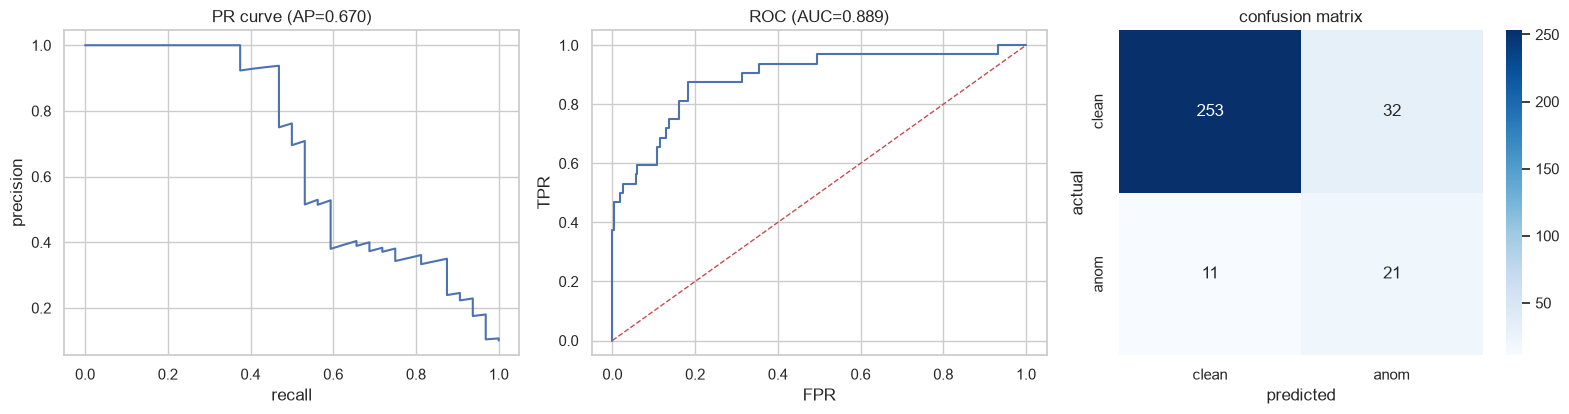

In [22]:
from sklearn.metrics import precision_recall_curve, roc_curve, confusion_matrix
prec, rec, _ = precision_recall_curve(inj.is_anomaly.astype(int), scores)
fpr, tpr, _  = roc_curve(inj.is_anomaly.astype(int), scores)
cm = confusion_matrix(inj.is_anomaly.astype(int), flags.astype(int))

fig, ax = plt.subplots(1, 3, figsize=(16, 4.3))
ax[0].plot(rec, prec); ax[0].set_xlabel("recall"); ax[0].set_ylabel("precision")
ax[0].set_title(f"PR curve (AP={det['pr_auc']:.3f})")
ax[1].plot(fpr, tpr); ax[1].plot([0,1],[0,1],"r--",lw=1)
ax[1].set_xlabel("FPR"); ax[1].set_ylabel("TPR"); ax[1].set_title(f"ROC (AUC={det['roc_auc']:.3f})")
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax[2],
            xticklabels=["clean","anom"], yticklabels=["clean","anom"])
ax[2].set_xlabel("predicted"); ax[2].set_ylabel("actual"); ax[2].set_title("confusion matrix")
plt.tight_layout(); plt.show()

In [23]:
# recall broken down by severity — do we catch the subtle ones?
print("recall by severity (fraction of injected faults caught):")
for lvl in ("low","moderate","severe"):
    m = inj.severity == lvl
    if m.sum():
        print(f"  {lvl:9s}: {flags[m].mean():.2f}  (n={int(m.sum())})")

recall by severity (fraction of injected faults caught):
  low      : 0.36  (n=11)
  moderate : 0.64  (n=11)
  severe   : 1.00  (n=10)


**Read:** severe and moderate faults are caught almost perfectly; the low band (a few σ,
by design near the noise floor) is the hard case and drives most misses.

## 15. Conclusions

**1. We tested baseline ML vs deep learning models.** The deeper
PyTorch MLP gave the best held-out accuracy (test RMSE ≈ 3.1 dB, R² ≈ 0.80), edging out
RandomForest and HistGradientBoosting (≈ 3.7–3.9 dB) and far ahead of linear regression
(≈ 5.0 dB). So here deep learning **is** justified — plausibly because SPL is a smooth,
continuous physical surface that suits a smooth function approximator, whereas trees give
piecewise-constant fits that generalise less well to unseen configurations under the grouped
split. The margin over the trees is modest (~0.8 dB RMSE).

so *production wise — training cost, interpretability, maintenance* may still favour the far simpler
tree. The value is that we *proved* the choice with held-out metrics rather than assuming it.

**2. Anomaly detection works, and simplest is best.** The residual detector on
the chosen regressor reaches PR-AUC ≈ 0.67 / ROC-AUC ≈ 0.89, catching **severe faults 100%**
and moderate ~64%; only sub-noise-floor 'low' faults (1–2σ, undetectable by design) are
largely missed.

**Limitations & next steps.** Only additive spikes were modelled (saturation/dropout/drift are
natural extensions); the operating threshold could be tuned to a target false-alarm rate to
lift the modest precision; the low-severity band is inherently near the noise floor; and a
larger, continuously-sampled dataset would give the deep models more room to pull ahead.